In [3]:
# ============================================================
# NEXT-DAY FORECASTING FOR PM2.5, PM10, AQI, AND TEMPERATURE
# Model: XGBoost + MultiOutputRegressor
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


# ============================================================
# 1) LOAD DATA
# ============================================================

FILE_PATH = "Feature_Ready_dataset.csv"
df = pd.read_csv(FILE_PATH)

# Standardize column names so the code is easier to read
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace("pm2.5", "pm25", regex=False)
)

# Parse datetime and sort time order
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.sort_values("datetime").reset_index(drop=True)


# ============================================================
# 2) TIME FEATURE ENGINEERING
# ============================================================

# Basic calendar features
df["dayofweek"] = df["datetime"].dt.dayofweek        # 0 = Monday, 6 = Sunday
df["dayofyear"] = df["datetime"].dt.dayofyear
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# Cyclical encodings for seasonality
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)


# ============================================================
# 3) LAG + ROLLING FEATURES
#    Use only past information for forecasting
# ============================================================

def add_time_series_features(frame: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Creates lag, rolling mean/std, and first-difference features.
    Rolling features are shifted by 1 so they use only past values.
    """
    lags = [1, 3, 7, 14]
    windows = [3, 7, 14]

    # Lag features
    for lag in lags:
        frame[f"{col}_lag{lag}"] = frame[col].shift(lag)

    # Rolling stats based on previous values only
    past_series = frame[col].shift(1)
    for win in windows:
        frame[f"{col}_roll{win}"] = past_series.rolling(win).mean()
        frame[f"{col}_std{win}"] = past_series.rolling(win).std()

    # Day-to-day change
    frame[f"{col}_diff1"] = frame[col].diff(1)

    return frame


# Create features for the four variables you want to forecast
for target_col in ["pm25", "pm10", "aqi", "temp"]:
    df = add_time_series_features(df, target_col)


# ============================================================
# 4) ENCODE CATEGORICAL FEATURES
# ============================================================

# season is categorical, so one-hot encode it
# day_name is not needed because dayofweek is already encoded numerically
# aqi_category is excluded because it is derived from AQI and can leak the answer
df = pd.get_dummies(df, columns=["season"], prefix="season", dtype=int)

# Drop columns that should not be used as model inputs
df = df.drop(columns=["aqi_category", "day_name"])


# ============================================================
# 5) CREATE NEXT-DAY TARGETS
# ============================================================

# We want to predict tomorrow's values from today's known data
df["target_pm25"] = df["pm25"].shift(-1)
df["target_pm10"] = df["pm10"].shift(-1)
df["target_aqi"] = df["aqi"].shift(-1)
df["target_temp"] = df["temp"].shift(-1)


# ============================================================
# 6) REMOVE ROWS WITH NaN
#    NaNs come from lag/rolling creation and the shifted targets
# ============================================================

df = df.dropna().reset_index(drop=True)


# ============================================================
# 7) BUILD FEATURE MATRIX X AND TARGET MATRIX y
# ============================================================

target_cols = ["target_pm25", "target_pm10", "target_aqi", "target_temp"]

# Exclude datetime and target columns
feature_cols = [c for c in df.columns if c not in (["datetime"] + target_cols)]

X = df[feature_cols]
y = df[target_cols]


# ============================================================
# 8) TIME-BASED TRAIN / TEST SPLIT
#    Never shuffle time-series data
# ============================================================

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train rows:", len(X_train))
print("Test rows :", len(X_test))
print("Features  :", X_train.shape[1])


# ============================================================
# 9) CREATE MULTI-OUTPUT XGBOOST MODEL
# ============================================================

base_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

# One forecasting system for all 4 outputs
model = MultiOutputRegressor(base_model, n_jobs=1)


# ============================================================
# 10) TRAIN MODEL
# ============================================================

print("\nTraining model...")
model.fit(X_train, y_train)
print("Training completed.")


# ============================================================
# 11) PREDICT ON TEST SET
# ============================================================

pred = model.predict(X_test)

pred_df = pd.DataFrame(
    pred,
    columns=["pred_pm25", "pred_pm10", "pred_aqi", "pred_temp"],
    index=y_test.index
)

def adjusted_r2(r2, n, p):

    adjusted = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

    return adjusted
# ============================================================
# 12) EVALUATION FUNCTION
# ============================================================

def evaluate_target(name: str, y_true: pd.Series, y_pred: np.ndarray) -> None:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X_test.shape[1]
    adj_r2 = adjusted_r2(r2, n, p)
    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.3f}")
    print(f"Adjusted R2  : {adj_r2:.3f}")

# ============================================================
# 13) PRINT METRICS
# ============================================================

print("\n================ MODEL PERFORMANCE ================")

evaluate_target("PM2.5", y_test["target_pm25"], pred_df["pred_pm25"])
evaluate_target("PM10", y_test["target_pm10"], pred_df["pred_pm10"])
evaluate_target("AQI", y_test["target_aqi"], pred_df["pred_aqi"])
evaluate_target("Temperature", y_test["target_temp"], pred_df["pred_temp"])


# ============================================================
# 14) SHOW SAMPLE PREDICTIONS
# ============================================================

results = pd.DataFrame(
    {
        "actual_pm25": y_test["target_pm25"].values,
        "pred_pm25": pred_df["pred_pm25"].values,
        "actual_pm10": y_test["target_pm10"].values,
        "pred_pm10": pred_df["pred_pm10"].values,
        "actual_aqi": y_test["target_aqi"].values,
        "pred_aqi": pred_df["pred_aqi"].values,
        "actual_temp": y_test["target_temp"].values,
        "pred_temp": pred_df["pred_temp"].values,
    }
)

print("\nSample predictions:")
print(results.head(10))


# ============================================================
# 15) OPTIONAL: FEATURE IMPORTANCE
#     Use the first estimator (PM2.5 model)
# ============================================================

importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": model.estimators_[0].feature_importances_,
    }
).sort_values("importance", ascending=False)

print("\nTop 15 important features for PM2.5 model:")
print(importance_df.head(15))


# ============================================================
# 16) SAVE MODEL + FEATURE LIST
# ============================================================

bundle = {
    "model": model,
    "feature_cols": feature_cols
}

# joblib.dump(bundle, "multioutput_xgboost_aqi_forecaster.pkl")
# print("\nSaved model to multioutput_xgboost_aqi_forecaster.pkl")


# ============================================================
# 17) OPTIONAL: PREDICT NEXT DAY FROM LATEST AVAILABLE ROW
#     This uses the most recent feature row only
# ============================================================

latest_row = X.tail(1)
next_day_pred = model.predict(latest_row)[0]

next_day_output = pd.DataFrame(
    [next_day_pred],
    columns=["pred_pm25", "pred_pm10", "pred_aqi", "pred_temp"]
)

print("\nNext-day prediction from latest row:")
print(next_day_output)

Train rows: 2054
Test rows : 514
Features  : 72

Training model...
Training completed.

================ MODEL PERFORMANCE ================

PM2.5
-----
MAE  : 5.51
RMSE : 8.10
R2   : 0.912
Adjusted R2  : 0.898

PM10
----
MAE  : 8.70
RMSE : 13.46
R2   : 0.892
Adjusted R2  : 0.874

AQI
---
MAE  : 8.80
RMSE : 12.56
R2   : 0.930
Adjusted R2  : 0.919

Temperature
-----------
MAE  : 1.75
RMSE : 2.49
R2   : 0.921
Adjusted R2  : 0.908

Sample predictions:
   actual_pm25  pred_pm25  actual_pm10  pred_pm10  actual_aqi    pred_aqi  \
0    58.016040  49.343258    61.081460  54.725327       152.0  133.891083   
1    57.472570  61.261528    60.298820  60.283199       152.0  147.679611   
2    54.527220  53.439350    59.435276  59.074150       148.0  139.187439   
3    65.256040  52.191357    69.414860  60.427814       156.0  138.765427   
4    61.226814  66.028061    68.001480  70.939545       154.0  156.750076   
5    53.975530  64.249115    60.230946  69.615456       146.0  153.038879   
6    46.

In [4]:
df

,datetime,pm25,pm10,tsp,temp,humidity,windspeed,winddir,sealevelpressure,visibility,...,temp_std14,temp_diff1,season_Autumn,season_Monsoon,season_Spring,season_Winter,target_pm25,target_pm10,target_aqi,target_temp
0,2016-09-15,28.500570,88.780580,260.71960,73.3,83.9,9.2,228.2,1015.3,4.5,...,1.815198,0.1,1,0,0,0,26.954376,84.966866,82.0,73.2
1,2016-09-16,26.954376,84.966866,259.29453,73.2,84.0,12.8,225.8,1013.8,4.7,...,1.720800,-0.1,1,0,0,0,25.408184,81.153160,79.0,72.6
2,2016-09-17,25.408184,81.153160,257.86948,72.6,85.0,10.3,205.7,1013.5,4.5,...,1.572777,-0.6,1,0,0,0,23.861990,77.339450,76.0,71.9
3,2016-09-18,23.861990,77.339450,256.44440,71.9,84.2,8.1,239.0,1014.6,4.8,...,1.571606,-0.7,1,0,0,0,28.116970,68.848590,85.0,74.3
4,2016-09-19,28.116970,68.848590,191.94330,74.3,80.7,9.2,270.8,1012.5,4.8,...,1.568859,2.4,1,0,0,0,18.825840,79.234260,65.0,74.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2563,2024-12-26,77.334724,109.378380,163.74797,52.1,67.2,9.2,268.3,1024.0,4.2,...,1.245122,-2.1,0,0,0,1,90.031290,122.154240,169.0,52.5
2564,2024-12-27,90.031290,122.154240,161.63747,52.5,69.4,4.7,160.8,1024.1,3.7,...,1.215106,0.4,0,0,0,1,115.462080,150.554240,182.0,51.5
2565,2024-12-28,115.462080,150.554240,191.30370,51.5,76.6,4.7,131.1,1023.8,2.8,...,1.184330,-1.0,0,0,0,1,104.691320,139.022640,176.0,54.8
2566,2024-12-29,104.691320,139.022640,201.82402,54.8,68.3,11.4,257.4,1021.4,3.3,...,1.009325,3.3,0,0,0,1,81.418270,107.658470,164.0,52.4


In [3]:
# ============================================================
# NEXT-DAY FORECASTING FOR PM2.5, PM10, AQI, AND TEMPERATURE
# Model: XGBoost + MultiOutputRegressor
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


# ============================================================
# 1) LOAD DATA
# ============================================================

FILE_PATH = "Feature_Ready_dataset.csv"
df = pd.read_csv(FILE_PATH)

# Standardize column names so the code is easier to read
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace("pm2.5", "pm25", regex=False)
)

# Parse datetime and sort time order
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.sort_values("datetime").reset_index(drop=True)


# ============================================================
# 2) TIME FEATURE ENGINEERING
# ============================================================

# Basic calendar features
df["dayofweek"] = df["datetime"].dt.dayofweek        # 0 = Monday, 6 = Sunday
df["dayofyear"] = df["datetime"].dt.dayofyear
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# Cyclical encodings for seasonality
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)


# ============================================================
# 3) LAG + ROLLING FEATURES
#    Use only past information for forecasting
# ============================================================

def add_time_series_features(frame: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Creates lag, rolling mean/std, and first-difference features.
    Rolling features are shifted by 1 so they use only past values.
    """
    lags = [1, 3, 7, 14]
    windows = [3, 7, 14]

    # Lag features
    for lag in lags:
        frame[f"{col}_lag{lag}"] = frame[col].shift(lag)

    # Rolling stats based on previous values only
    past_series = frame[col].shift(1)
    for win in windows:
        frame[f"{col}_roll{win}"] = past_series.rolling(win).mean()
        frame[f"{col}_std{win}"] = past_series.rolling(win).std()

    # Day-to-day change
    frame[f"{col}_diff1"] = frame[col].diff(1)

    return frame


# Create features for the four variables you want to forecast
for target_col in ["pm25", "pm10", "aqi", "temp"]:
    df = add_time_series_features(df, target_col)


# ============================================================
# 4) ENCODE CATEGORICAL FEATURES
# ============================================================

# season is categorical, so one-hot encode it
# day_name is not needed because dayofweek is already encoded numerically
# aqi_category is excluded because it is derived from AQI and can leak the answer
df = pd.get_dummies(df, columns=["season"], prefix="season", dtype=int)

# Drop columns that should not be used as model inputs
df = df.drop(columns=["aqi_category", "day_name"])


# ============================================================
# 5) CREATE NEXT-DAY TARGETS
# ============================================================

# We want to predict tomorrow's values from today's known data
df["target_pm25"] = df["pm25"].shift(-1)
df["target_pm10"] = df["pm10"].shift(-1)
df["target_aqi"] = df["aqi"].shift(-1)
df["target_temp"] = df["temp"].shift(-1)


# ============================================================
# 6) REMOVE ROWS WITH NaN
#    NaNs come from lag/rolling creation and the shifted targets
# ============================================================

df = df.dropna().reset_index(drop=True)


# ============================================================
# 7) BUILD FEATURE MATRIX X AND TARGET MATRIX y
# ============================================================

target_cols = ["target_pm25", "target_pm10", "target_aqi", "target_temp"]

# Exclude datetime and target columns
feature_cols = [c for c in df.columns if c not in (["datetime"] + target_cols)]

X = df[feature_cols]
y = df[target_cols]


# ============================================================
# 8) TIME-BASED TRAIN / TEST SPLIT
#    Never shuffle time-series data
# ============================================================

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train rows:", len(X_train))
print("Test rows :", len(X_test))
print("Features  :", X_train.shape[1])


# ============================================================
# 9) CREATE MULTI-OUTPUT XGBOOST MODEL
# ============================================================

base_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

# One forecasting system for all 4 outputs
model = MultiOutputRegressor(base_model, n_jobs=1)


# ============================================================
# 10) TRAIN MODEL
# ============================================================

print("\nTraining model...")
model.fit(X_train, y_train)
print("Training completed.")


# ============================================================
# 11) PREDICT ON TEST SET
# ============================================================

pred = model.predict(X_test)

pred_df = pd.DataFrame(
    pred,
    columns=["pred_pm25", "pred_pm10", "pred_aqi", "pred_temp"],
    index=y_test.index
)

def adjusted_r2(r2, n, p):

    adjusted = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

    return adjusted
# ============================================================
# 12) EVALUATION FUNCTION
# ============================================================

def evaluate_target(name: str, y_true: pd.Series, y_pred: np.ndarray) -> None:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X_test.shape[1]
    adj_r2 = adjusted_r2(r2, n, p)
    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.3f}")
    print(f"Adjusted R2  : {adj_r2:.3f}")

# ============================================================
# 13) PRINT METRICS
# ============================================================

print("\n================ MODEL PERFORMANCE ================")

evaluate_target("PM2.5", y_test["target_pm25"], pred_df["pred_pm25"])
evaluate_target("PM10", y_test["target_pm10"], pred_df["pred_pm10"])
evaluate_target("AQI", y_test["target_aqi"], pred_df["pred_aqi"])
evaluate_target("Temperature", y_test["target_temp"], pred_df["pred_temp"])


# ============================================================
# 14) SHOW SAMPLE PREDICTIONS
# ============================================================

results = pd.DataFrame(
    {
        "actual_pm25": y_test["target_pm25"].values,
        "pred_pm25": pred_df["pred_pm25"].values,
        "actual_pm10": y_test["target_pm10"].values,
        "pred_pm10": pred_df["pred_pm10"].values,
        "actual_aqi": y_test["target_aqi"].values,
        "pred_aqi": pred_df["pred_aqi"].values,
        "actual_temp": y_test["target_temp"].values,
        "pred_temp": pred_df["pred_temp"].values,
    }
)

print("\nSample predictions:")
print(results.head(10))


# ============================================================
# 15) OPTIONAL: FEATURE IMPORTANCE
#     Use the first estimator (PM2.5 model)
# ============================================================

importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": model.estimators_[0].feature_importances_,
    }
).sort_values("importance", ascending=False)

print("\nTop 15 important features for PM2.5 model:")
print(importance_df.head(15))


# ============================================================
# 16) SAVE MODEL + FEATURE LIST
# ============================================================

# bundle = {
#     "model": model,
#     "feature_cols": feature_cols
# }

# joblib.dump(bundle, "multioutput_xgboost_aqi_forecaster.pkl")
# print("\nSaved model to multioutput_xgboost_aqi_forecaster.pkl")


# ============================================================
# 17) OPTIONAL: PREDICT NEXT DAY FROM LATEST AVAILABLE ROW
#     This uses the most recent feature row only
# ============================================================

latest_row = X.tail(1)
next_day_pred = model.predict(latest_row)[0]

next_day_output = pd.DataFrame(
    [next_day_pred],
    columns=["pred_pm25", "pred_pm10", "pred_aqi", "pred_temp"]
)

print("\nNext-day prediction from latest row:")
print(next_day_output)

Train rows: 2054
Test rows : 514
Features  : 72

Training model...
Training completed.

================ MODEL PERFORMANCE ================

PM2.5
-----
MAE  : 5.51
RMSE : 8.10
R2   : 0.912
Adjusted R2  : 0.898

PM10
----
MAE  : 8.70
RMSE : 13.46
R2   : 0.892
Adjusted R2  : 0.874

AQI
---
MAE  : 8.80
RMSE : 12.56
R2   : 0.930
Adjusted R2  : 0.919

Temperature
-----------
MAE  : 1.75
RMSE : 2.49
R2   : 0.921
Adjusted R2  : 0.908

Sample predictions:
   actual_pm25  pred_pm25  actual_pm10  pred_pm10  actual_aqi    pred_aqi  \
0    58.016040  49.343258    61.081460  54.725327       152.0  133.891083   
1    57.472570  61.261528    60.298820  60.283199       152.0  147.679611   
2    54.527220  53.439350    59.435276  59.074150       148.0  139.187439   
3    65.256040  52.191357    69.414860  60.427814       156.0  138.765427   
4    61.226814  66.028061    68.001480  70.939545       154.0  156.750076   
5    53.975530  64.249115    60.230946  69.615456       146.0  153.038879   
6    46.

In [4]:
# ============================================================
# TRAIN VS TEST R²
# ============================================================

from sklearn.metrics import r2_score

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

targets = [
    "PM2.5",
    "PM10",
    "AQI",
    "Temperature"
]

print("\n========== OVERFITTING CHECK ==========\n")

for i, target in enumerate(targets):

    train_r2 = r2_score(
        y_train.iloc[:, i],
        train_pred[:, i]
    )

    test_r2 = r2_score(
        y_test.iloc[:, i],
        test_pred[:, i]
    )

    gap = train_r2 - test_r2

    print(f"{target}")
    print(f"Train R² : {train_r2:.4f}")
    print(f"Test  R² : {test_r2:.4f}")
    print(f"Gap      : {gap:.4f}")

    if gap < 0.05:
        print("Status   : Good Generalization")

    elif gap < 0.10:
        print("Status   : Mild Overfitting")

    else:
        print("Status   : Possible Overfitting")

    print("-" * 40)


========== OVERFITTING CHECK ==========

PM2.5
Train R² : 0.9860
Test  R² : 0.9121
Gap      : 0.0739
Status   : Mild Overfitting
----------------------------------------
PM10
Train R² : 0.9805
Test  R² : 0.8918
Gap      : 0.0886
Status   : Mild Overfitting
----------------------------------------
AQI
Train R² : 0.9866
Test  R² : 0.9302
Gap      : 0.0564
Status   : Mild Overfitting
----------------------------------------
Temperature
Train R² : 0.9936
Test  R² : 0.9205
Gap      : 0.0731
Status   : Mild Overfitting
----------------------------------------


##### The model shows a small train-test performance gap, indicating mild overfitting, which is expected for a powerful ensemble model such as XGBoost. However, the test R² values remain above 0.89 for all target variables, suggesting strong generalization ability.

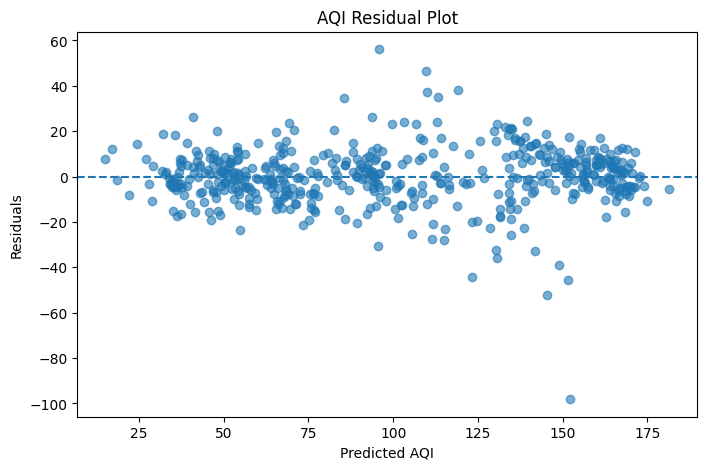

In [5]:
# ============================================================
# AQI RESIDUAL PLOT
# ============================================================

import matplotlib.pyplot as plt

# AQI residuals
aqi_actual = y_test["target_aqi"]
aqi_pred = test_pred[:, 2]

aqi_residuals = aqi_actual - aqi_pred

plt.figure(figsize=(8,5))

plt.scatter(
    aqi_pred,
    aqi_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")

plt.title("AQI Residual Plot")

plt.show()

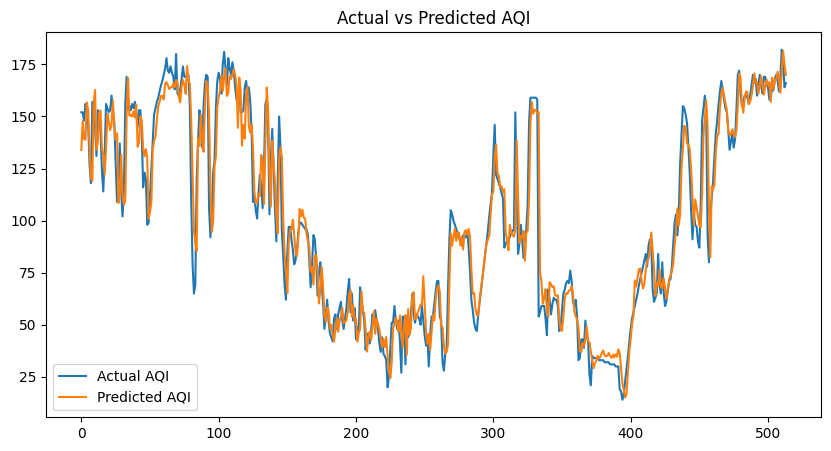

In [6]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test["target_aqi"].values,
    label="Actual AQI"
)

plt.plot(
    test_pred[:,2],
    label="Predicted AQI"
)

plt.title("Actual vs Predicted AQI")
plt.legend()

plt.show()

##### The predicted AQI values closely follow the actual AQI trend throughout the testing period. The model successfully captures seasonal fluctuations and pollution peaks, although a small smoothing effect is observed during sudden AQI spikes.

In [7]:
targets = [
    ("PM2.5", y_test["target_pm25"], test_pred[:,0]),
    ("PM10", y_test["target_pm10"], test_pred[:,1]),
    ("AQI", y_test["target_aqi"], test_pred[:,2]),
    ("Temperature", y_test["target_temp"], test_pred[:,3])
]

for name, actual, pred in targets:

    residuals = actual - pred

    bias = np.mean(residuals)
    variance = np.var(residuals)
    std_dev = np.std(residuals)

    print(f"\n{name}")
    print(f"Bias              : {bias:.3f}")
    print(f"Residual Variance : {variance:.3f}")
    print(f"Residual Std Dev  : {std_dev:.3f}")


PM2.5
Bias              : -0.181
Residual Variance : 65.649
Residual Std Dev  : 8.102

PM10
Bias              : -1.718
Residual Variance : 178.107
Residual Std Dev  : 13.346

AQI
Bias              : 0.121
Residual Variance : 157.854
Residual Std Dev  : 12.564

Temperature
Bias              : 0.984
Residual Variance : 5.231
Residual Std Dev  : 2.287
